# 第9〜10回：ベイズ最適化（Bayesian Optimization, BO）


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rsimd/NITIC-ConbinatorialOptimization/blob/master/lecture09_bayesian_optimization.ipynb)


## 0. このページで学ぶこと

このページでは，評価に時間や費用がかかるブラックボックス関数を，少ない評価回数でよい値へ近づける方法として **ベイズ最適化**（Bayesian Optimization, BO）を学ぶ。

到達目標は次の 4 つである。特に，このページでは式を読むだけで終わらせず，図を見ながら「平均が動く」「不確かさが縮む」「獲得関数が次の点を選ぶ」という流れを追う。

- ブラックボックス最適化で「評価回数を節約する」ことの意味を説明できる。
- ガウス過程回帰（Gaussian Process Regression, GPR）が，平均だけでなく不確かさも返す理由を説明できる。
- 獲得関数（acquisition function）が，探索（exploration）と活用（exploitation）の折り合いをつける仕組みを説明できる。
- 1 次元の例で，GP と獲得関数を用いた逐次最適化を実装できる。



## 1. ベイズ最適化が解きたい問題

目的関数を

$$
f: \mathcal{X} \to \mathbb{R}
$$

とする。ここで $\mathcal{X}$ は探索空間であり，$f(\boldsymbol{x})$ は候補 $\boldsymbol{x}$ を実際に試したときの評価値である。最小化問題なら，目標は

$$
\boldsymbol{x}^{\star}
= \operatorname*{arg\,min}_{\boldsymbol{x} \in \mathcal{X}} f(\boldsymbol{x})
$$

である。

ただし，ベイズ最適化が特に役立つのは，次のような厳しい状況である。

- $f$ の式が分からない，または微分できない。
- 1 回の評価に時間，費用，実験材料，計算資源がかかる。
- 何千回，何万回も評価するランダム探索や進化計算は使いにくい。
- 評価結果にはノイズが含まれることがある。

たとえば，材料合成条件の探索，化学実験の条件設計，機械学習モデルのハイパーパラメータ調整，シミュレーションの入力条件探索などが典型例である。

第4〜8回で扱った PSO，DE，CMA-ES は，多数の候補を動かしながら探索する。これに対してベイズ最適化は，**これまでに観測した少数のデータから目的関数の地図を推定し，次に調べる 1 点を慎重に選ぶ**。


## 2. ベイズ最適化の全体像

ベイズ最適化は，次の 2 つを交互に使う。

1. **代理モデル**（surrogate model）  
   高価な目的関数 $f$ の代わりに，観測済みデータから $f$ を近似する確率モデルを作る。代表例がガウス過程回帰である。

2. **獲得関数**（acquisition function）  
   代理モデルの予測平均と予測不確かさを使って，次に本物の $f$ を評価する候補を決める。

手順を疑似コードで書くと，次のようになる。

```text
入力: 探索空間 X, 初期観測 D0 = {(x_i, y_i)}
for t = 0, 1, 2, ...:
    1. 観測データ D_t で代理モデルを学習する
    2. 各候補 x について獲得関数 a_t(x) を計算する
    3. x_{t+1} = argmax_x a_t(x) を選ぶ
    4. 高価な目的関数を 1 回だけ評価し，y_{t+1} = f(x_{t+1}) を得る
    5. D_{t+1} = D_t ∪ {(x_{t+1}, y_{t+1})} とする
出力: 観測済み点の中で最もよかった候補
```

重要なのは，代理モデルで最適解を直接決めるのではない点である。代理モデルは「どこが良さそうか」と「どこがまだ分からないか」を見積もるための道具であり，最後に値を確かめるのは本物の目的関数である。


### 2.1 ガウス過程は BO のどこで使うのか

ここで，次の節に出てくる **ガウス過程**（Gaussian Process, GP）の位置づけを先に確認しておく。

ベイズ最適化では，本物の目的関数 $f$ を何度も評価できない。そこで，観測済みデータ

$$
D_t = \{(\boldsymbol{x}_1,y_1),\ldots,(\boldsymbol{x}_t,y_t)\}
$$

だけを使って，「まだ評価していない点では $f$ がどのくらいの値になりそうか」を推定する。この推定役が **代理モデル** である。

ガウス過程は，この代理モデルとしてよく使われる。理由は，候補点 $\boldsymbol{x}$ ごとに次の 2 つを同時に返せるからである。

- **予測平均** $\mu(\boldsymbol{x})$: その点の値がどれくらいになりそうか。
- **予測不確かさ** $\sigma(\boldsymbol{x})$: その予測にどれくらい自信がないか。

獲得関数は，この $\mu(\boldsymbol{x})$ と $\sigma(\boldsymbol{x})$ を材料にして，次に調べる点を決める。つまり GP は，BO の中で「目的関数の地図を確率付きで描く」役割を持つ。


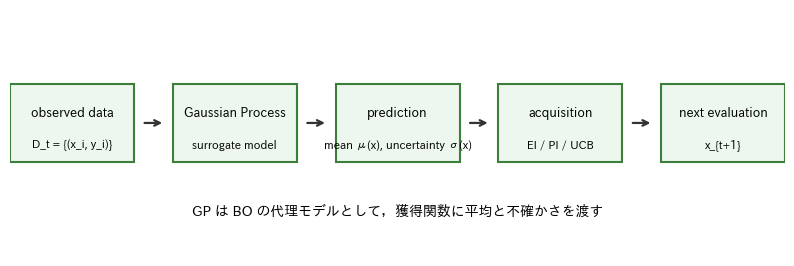

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
steps = [
    ("observed data", "D_t = {(x_i, y_i)}"),
    ("Gaussian Process", "surrogate model"),
    ("prediction", "mean μ(x), uncertainty σ(x)"),
    ("acquisition", "EI / PI / UCB"),
    ("next evaluation", "x_{t+1}"),
]
xs = np.linspace(0.08, 0.92, len(steps))
for i, (xpos, (title, subtitle)) in enumerate(zip(xs, steps)):
    box = plt.Rectangle((xpos - 0.08, 0.38), 0.16, 0.32, facecolor="#edf7ed", edgecolor="#3b7f3b", linewidth=1.5)
    ax.add_patch(box)
    ax.text(xpos, 0.58, title, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(xpos, 0.45, subtitle, ha="center", va="center", fontsize=8)
    if i < len(steps) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.09, 0.54), xytext=(xpos + 0.09, 0.54), arrowprops=dict(arrowstyle="->", lw=1.6, color="#333333"))
ax.text(0.50, 0.18, "GP は BO の代理モデルとして，獲得関数に平均と不確かさを渡す", ha="center", va="center", fontsize=10)
plt.show()

## 3. ガウス過程を丁寧に見る

第2節で見たように，ベイズ最適化では代理モデルが必要である。代理モデルに求めたい性質は，単に「予測値を出す」ことだけではない。次の候補点を選ぶためには，予測がどれくらい信用できるかも必要である。

たとえば，ある候補 $x_A$ では予測値が高いが観測済み点に近く，すでにだいたい分かっているとする。一方，別の候補 $x_B$ では予測値は少し低いが，まだ一度も調べていない領域にあり，不確かさが大きいとする。このとき BO は，$x_A$ をさらに詰めるべきか，$x_B$ を試して未知の山を探すべきかを判断したい。

この判断には，候補点ごとの **予測値と予測の不確かさ** が必要である。ガウス過程回帰は，まさにこの 2 つを返す回帰モデルである。

### 3.1 まず「普通の回帰」と何が違うか

通常の回帰では，観測データから 1 本の関数 $\hat{f}$ を作ることが多い。たとえば，線形回帰なら「この直線がもっともらしい」，決定木なら「この分割がもっともらしい」という形で，点 $\boldsymbol{x}$ に対する予測値を返す。

しかし BO では，予測値だけでは足りない。まだ観測していない場所を試す価値を測るために，「その予測がどれくらい不確かか」も必要である。

ガウス過程（Gaussian Process, GP）は，この目的に合ったモデルである。GP は 1 本の関数を最初から決め打ちするのではなく，**あり得る関数全体に確率分布を置く**。観測データが増えると，その分布が条件付けられ，あり得る関数の範囲が狭くなる。

### 3.2 「関数の分布」として考える

「関数に確率分布を置く」と聞くと難しく感じるかもしれない。有限個の入力点だけを考えると分かりやすい。

入力点 $\boldsymbol{x}_1, \ldots, \boldsymbol{x}_n$ を選ぶと，それらの関数値

$$
\boldsymbol{f}
= [f(\boldsymbol{x}_1), \ldots, f(\boldsymbol{x}_n)]^{\mathsf{T}}
$$

は $n$ 次元ベクトルである。GP では，このベクトルが多変量正規分布に従うと考える。どの入力点の集まりを選んでも，対応する関数値ベクトルが多変量正規分布になる，という仮定である。

この性質を

$$
f(\boldsymbol{x}) \sim \mathcal{GP}\left(
\underbrace{m(\boldsymbol{x})}_{\text{平均関数}},\;
\underbrace{k(\boldsymbol{x}, \boldsymbol{x}')}_{\text{カーネル / 共分散関数}}
\right)
$$

と書く。

ここで

- $m(\boldsymbol{x})$ は平均関数であり，観測前に「このあたりの値だろう」と置く中心である。
- $k(\boldsymbol{x}, \boldsymbol{x}')$ はカーネル関数（共分散関数）であり，2 つの入力がどれくらい似た値を取りやすいかを表す。
  - 特に $k(\boldsymbol{x}, \boldsymbol{x})$ はその点での分散に対応する。
  - $k(\boldsymbol{x}, \boldsymbol{x}')$ は 2 点間の共分散であり，点どうしの関係を表す。

この関数はそのまま標準偏差ではないが，予測の不確かさを決める役割を持つ。

授業では，平均関数を 0 とする。これは「標準化された目的変数について，観測前には上下どちらにも偏らない」と考える近似である。


この状況を図にすると，次のようになる。$x_A$ は観測点に近く，予測平均は高いが不確かさは小さい。$x_B$ は観測点から離れており，予測平均は少し低いが不確かさが大きい。

![予測平均と不確かさによる exploitation と exploration の違い](assets/bo_exploitation_exploration.png)

図の読み方を整理しておく。

- 青い曲線は GP の予測平均である。現時点の代理モデルが「このあたりの値になりそうだ」と考えている中心を表す。
- 薄い青い帯は予測の不確かさである。観測点が多い左側では帯が細く，観測点が少ない右側では帯が太い。
- 赤い点は，すでに本物の目的関数を評価した観測点である。観測点の近くでは，GP は比較的自信を持って予測できる。
- $x_A$ は予測平均が高く，観測点にも近い。したがって「すでに良さそうだと分かっている場所をさらに使う」候補であり，活用（exploitation）の例である。
- $x_B$ は予測平均だけを見ると $x_A$ より少し低いが，不確かさが大きい。したがって「まだよく分からない場所に大きな値が隠れているかもしれない」と考えて試す候補であり，探索（exploration）の例である。

BO は，常に $x_A$ だけを選ぶわけでも，常に $x_B$ だけを選ぶわけでもない。獲得関数は，予測平均 $\mu(x)$ と不確かさ $\sigma(x)$ を組み合わせ，今は活用すべきか，探索すべきかを数値として比較する。



### 3.3 GP の事前分布を描いてみる

「関数の分布」という言い方は抽象的である。そこで，まだ観測データが 1 点もない状態で，GP から関数を何本かサンプリングしてみる。

次の図では，横軸の各 $x$ に対する値をまとめて多変量正規分布から発生させている。1 本 1 本の曲線が「あり得る関数」の候補である。観測前なので，どの曲線が正しいかはまだ分からない。


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_fontja
from scipy.stats import norm

np.random.seed(7)


def rbf_kernel_matrix(x_left: np.ndarray, x_right: np.ndarray, length_scale: float = 0.6, variance: float = 1.0) -> np.ndarray:
    """1 次元入力に対する RBF カーネル行列を返す。"""
    x_left = np.asarray(x_left).reshape(-1, 1)
    x_right = np.asarray(x_right).reshape(1, -1)
    squared_distance = (x_left - x_right) ** 2
    return variance * np.exp(-0.5 * squared_distance / length_scale**2)

x_prior = np.linspace(0.0, 4.0, 160)
prior_mean = np.zeros_like(x_prior)
prior_cov = rbf_kernel_matrix(x_prior, x_prior, length_scale=0.55, variance=1.0)
prior_cov += 1e-8 * np.eye(len(x_prior))
prior_samples = np.random.multivariate_normal(prior_mean, prior_cov, size=6)

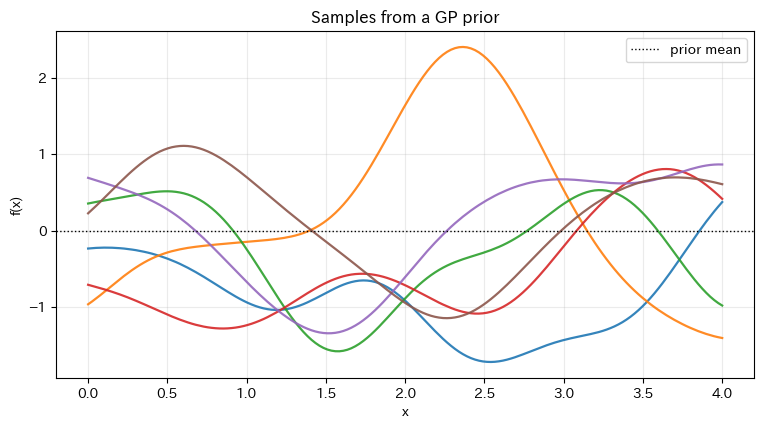

In [3]:
plt.figure(figsize=(9, 4.5))
for sample in prior_samples:
    plt.plot(x_prior, sample, linewidth=1.6, alpha=0.9)
plt.axhline(0.0, color="black", linewidth=1.0, linestyle=":", label="prior mean")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Samples from a GP prior")
plt.grid(alpha=0.25)
plt.legend(loc="best")
plt.show()


曲線はランダムだが，完全にギザギザではない。これは RBF カーネルが「近い $x$ では似た値になりやすい」という仮定を入れているからである。

ここで大事なのは，GP が 1 本の関数を決め打ちしていない点である。観測前にはたくさんの関数が候補としてあり，観測を入れるたびに候補の範囲が絞られていく。


### 3.4 カーネルは「近い入力は近い値を取りやすい」という仮定である

よく使われる RBF カーネル（Gaussian kernel, squared exponential kernel）は

$$
k(\boldsymbol{x}, \boldsymbol{x}')
= \sigma_f^2
\exp\left(
-\frac{\|\boldsymbol{x} - \boldsymbol{x}'\|^2}{2\ell^2}
\right)
$$

である。

この式の意味を順番に見る。

- $\|\boldsymbol{x} - \boldsymbol{x}'\|$ が小さいと，指数の中身は 0 に近くなり，$k$ は大きくなる。
- $\|\boldsymbol{x} - \boldsymbol{x}'\|$ が大きいと，指数の中身は大きな負の値になり，$k$ は 0 に近づく。
- $\ell$ は length scale である。大きいほど，遠く離れた点も似た値を取りやすいと考える。
- $\sigma_f^2$ は関数値の振れ幅を表す。

この式は，入力の距離が小さいほど $k(\boldsymbol{x}, \boldsymbol{x}')$ の値が大きくなることを示している。すなわち，$\boldsymbol{x}$ と $\boldsymbol{x}'$ が近いほど，対応する関数値 $f(\boldsymbol{x})$ と $f(\boldsymbol{x}')$ が似た値になりやすいという仮定を表す。

つまり RBF カーネルは，「入力が近ければ関数値も似ているはずだ」という滑らかさの仮定を数式にしたものである。皆さんはどう思うだろうか。もし目的関数が急にギザギザ変わるなら，この仮定は強すぎるかもしれない。


### 3.5 length scale を変えると何が変わるか

RBF カーネルの length scale $\ell$ は，GP の滑らかさを強く左右する。式だけでは見えにくいので，同じ乱数の考え方で $\ell$ を変えた事前サンプルを比べる。

- $\ell$ が小さい: 近い点だけが強く関係し，曲線は細かく揺れやすい。
- $\ell$ が大きい: 離れた点も似た値になりやすく，曲線はゆっくり変化する。

BO では，この仮定が探索の仕方にも影響する。実際の目的関数より $\ell$ を大きく見積もりすぎると，細かい山を見逃すことがある。逆に小さすぎると，不確かさが局所的に残りすぎて探索が落ち着きにくい。


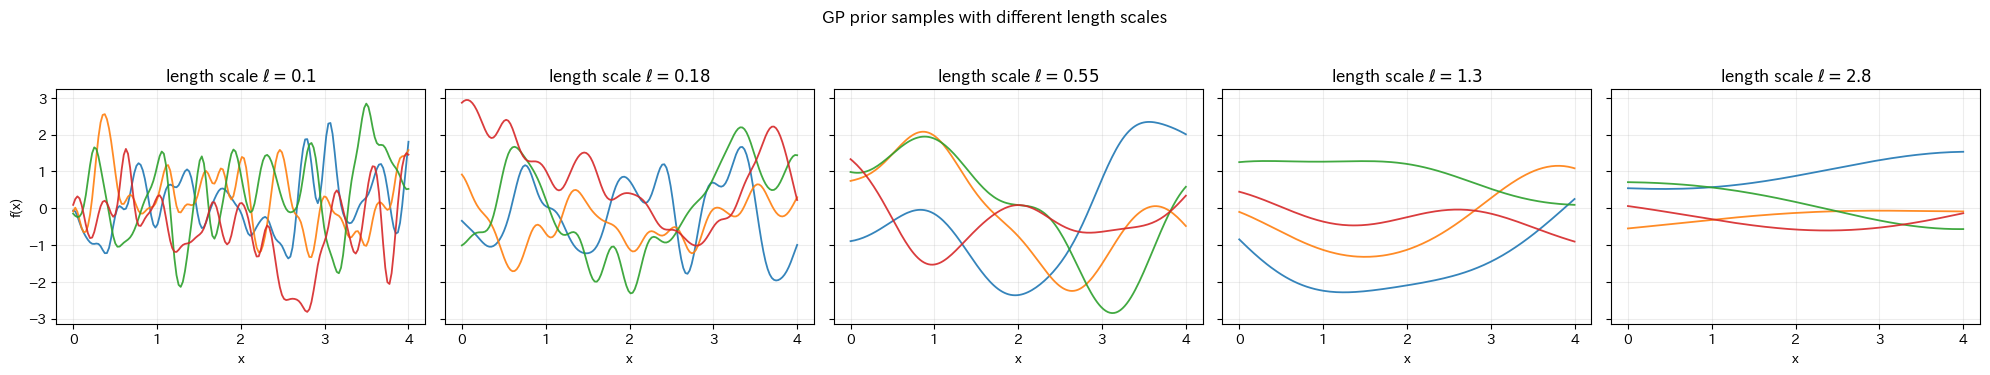

In [4]:
length_scales = [0.1, 0.18, 0.55, 1.30, 2.80]
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6), sharex=True, sharey=True)

for ax, ell in zip(axes, length_scales):
    cov = rbf_kernel_matrix(x_prior, x_prior, length_scale=ell, variance=1.0)
    cov += 1e-8 * np.eye(len(x_prior))
    samples = np.random.multivariate_normal(np.zeros_like(x_prior), cov, size=4)
    for sample in samples:
        ax.plot(x_prior, sample, linewidth=1.3, alpha=0.9)
    ax.set_title(f"length scale $\\ell = {ell}$")
    ax.set_xlabel("x")
    ax.grid(alpha=0.22)
axes[0].set_ylabel("f(x)")
fig.suptitle("GP prior samples with different length scales", y=1.03)
plt.tight_layout()
plt.show()


### 3.6 観測データを条件にした予測分布

観測データを

$$
X = [\boldsymbol{x}_1, \ldots, \boldsymbol{x}_n]^{\mathsf{T}},
\quad
\boldsymbol{y} = [y_1, \ldots, y_n]^{\mathsf{T}}
$$

とする。観測にはノイズがあるとして

$$
y_i = f(\boldsymbol{x}_i) + \epsilon_i,
\quad
\epsilon_i \sim \mathcal{N}(0, \sigma_n^2)
$$

を仮定する。

新しい点 $\boldsymbol{x}_{*}$ での関数値 $f_{*}=f(\boldsymbol{x}_{*})$ を予測したい。GP の仮定では，観測値 $\boldsymbol{y}$ と $f_{*}$ は同時に正規分布に従う。平均 0 の場合，その共分散は

$$
\begin{bmatrix}
\boldsymbol{y} \\
f_{*}
\end{bmatrix}
\sim
\mathcal{N}\left(
\boldsymbol{0},
\begin{bmatrix}
K(X, X) + \sigma_n^2 I & \boldsymbol{k}_{*} \\
\boldsymbol{k}_{*}^{\mathsf{T}} & k_{**}
\end{bmatrix}
\right)
$$

である。ここで

$$
K(X, X)_{ij}=k(\boldsymbol{x}_i,\boldsymbol{x}_j),
\quad
\boldsymbol{k}_{*} = [k(\boldsymbol{x}_1,\boldsymbol{x}_{*}),\ldots,k(\boldsymbol{x}_n,\boldsymbol{x}_{*})]^{\mathsf{T}},
\quad
k_{**}=k(\boldsymbol{x}_{*},\boldsymbol{x}_{*})
$$

である。

:::{hint}
:open: false

- $K(X,X)$ は観測入力 $\{\boldsymbol{x}_1,\ldots,\boldsymbol{x}_n\}$ 間の共分散行列で、$(i,j)$ 成分が $k(\boldsymbol{x}_i,\boldsymbol{x}_j)$ である。
- 観測値 $\boldsymbol{y}$ にはノイズ $\epsilon_i \sim \mathcal{N}(0,\sigma_n^2)$ が入るので、観測データの共分散として $K(X,X)+\sigma_n^2 I$ を使う。これは「関数の共分散」だけでなく「観測ノイズも含めた共分散」を表す。
- $f_{*}=f(\boldsymbol{x}_{*})$ は新しい点 $\boldsymbol{x}_{*}$ での真の関数値である。予測式は、この未知の $f_{*}$ の条件付き分布を求めるもので、単なる点推定 $\hat{y}$ ではない。
- したがって
  - $\mu(\boldsymbol{x}_{*})$ は観測データを踏まえた予測の平均
  - $\sigma^2(\boldsymbol{x}_{*})$ はその予測分布の分散
  という意味で読むと、GP の「平均と不確かさを同時に返す」という性質がつかみやすい。

:::

多変量正規分布の条件付き分布の公式から，予測分布は

$$
f_{*}\mid X,\boldsymbol{y},\boldsymbol{x}_{*}
\sim
\mathcal{N}\left(\mu(\boldsymbol{x}_{*}),\sigma^2(\boldsymbol{x}_{*})\right)
$$

となり，

$$
\mu(\boldsymbol{x}_{*})
= \boldsymbol{k}_{*}^{\mathsf{T}}
\left(K + \sigma_n^2 I\right)^{-1}
\boldsymbol{y}
$$

$$
\sigma^2(\boldsymbol{x}_{*})
= k_{**}
- \boldsymbol{k}_{*}^{\mathsf{T}}
\left(K + \sigma_n^2 I\right)^{-1}
\boldsymbol{k}_{*}
$$

である。

:::{hint} 条件付き正規分布から GP の予測式を導く
:open: false

次のように記号を短く置く。

$$
A = K(X,X)+\sigma_n^2 I,
\quad
\boldsymbol{b}=\boldsymbol{k}_{*},
\quad
c=k_{**}
$$

この置き換えで本当にこのブロック行列になることを，成分ごとに確認しておく。

まず GP の定義から，有限個の関数値を並べた

$$
\boldsymbol{f}=[f(\boldsymbol{x}_1),\ldots,f(\boldsymbol{x}_n)]^{\mathsf{T}},
\quad
f_{*}=f(\boldsymbol{x}_{*})
$$

は同時正規分布に従う。また，平均を 0 としたので，観測ノイズも平均 0 なら $\boldsymbol{y}$ と $f_{*}$ の平均も 0 である。したがって，あとは共分散だけを決めればよい。

観測値は $y_i=f(\boldsymbol{x}_i)+\epsilon_i$ で，ノイズは互いに独立，かつ関数値とも独立である。よって観測値どうしの共分散は

$$
\operatorname{Cov}(y_i,y_j)
=\operatorname{Cov}(f(\boldsymbol{x}_i)+\epsilon_i,
                         f(\boldsymbol{x}_j)+\epsilon_j)
=k(\boldsymbol{x}_i,\boldsymbol{x}_j)+\sigma_n^2\delta_{ij}
$$

となる。ここで $\delta_{ij}$ は $i=j$ のとき 1，それ以外で 0 になる記号である。したがって，左上ブロックは $K(X,X)+\sigma_n^2I$ である。

次に，観測値 $y_i$ と新しい点の関数値 $f_{*}$ の共分散は

$$
\operatorname{Cov}(y_i,f_{*})
=\operatorname{Cov}(f(\boldsymbol{x}_i)+\epsilon_i, f(\boldsymbol{x}_{*}))
=k(\boldsymbol{x}_i,\boldsymbol{x}_{*})
$$

である。ノイズ $\epsilon_i$ は $f_{*}$ と独立なので，ノイズ由来の項は 0 になる。この成分を縦に並べたものが $\boldsymbol{k}_{*}$ である。最後に

$$
\operatorname{Var}(f_{*})=k(\boldsymbol{x}_{*},\boldsymbol{x}_{*})=k_{**}
$$

である。以上をまとめると，同時分布は

$$
\begin{bmatrix}
\boldsymbol{y} \\
f_{*}
\end{bmatrix}
\sim
\mathcal{N}\left(
\boldsymbol{0},
\begin{bmatrix}
K(X,X)+\sigma_n^2I & \boldsymbol{k}_{*} \\
\boldsymbol{k}_{*}^{\mathsf{T}} & k_{**}
\end{bmatrix}
\right)
$$

であり，これは $A=K(X,X)+\sigma_n^2I$，$\boldsymbol{b}=\boldsymbol{k}_{*}$，$c=k_{**}$ と置けば

$$
\begin{bmatrix}
\boldsymbol{y} \\
f_{*}
\end{bmatrix}
\sim
\mathcal{N}\left(
\boldsymbol{0},
\begin{bmatrix}
A & \boldsymbol{b} \\
\boldsymbol{b}^{\mathsf{T}} & c
\end{bmatrix}
\right)
$$

と書ける。

ここで，一般に

$$
\begin{bmatrix}
\boldsymbol{u} \\
v
\end{bmatrix}
\sim
\mathcal{N}\left(
\boldsymbol{0},
\begin{bmatrix}
A & \boldsymbol{b} \\
\boldsymbol{b}^{\mathsf{T}} & c
\end{bmatrix}
\right)
$$

であるとき，$v$ を $\boldsymbol{u}$ で条件付けた分布は

$$
v\mid \boldsymbol{u}
\sim
\mathcal{N}\left(
\boldsymbol{b}^{\mathsf{T}}A^{-1}\boldsymbol{u},
\;c-\boldsymbol{b}^{\mathsf{T}}A^{-1}\boldsymbol{b}
\right)
$$

となる。これは多変量正規分布の標準的な条件付き分布の公式である。

この公式に

$$
\boldsymbol{u}=\boldsymbol{y},
\quad
v=f_{*},
\quad
A=K(X,X)+\sigma_n^2 I,
\quad
\boldsymbol{b}=\boldsymbol{k}_{*},
\quad
c=k_{**}
$$

を代入すると，

$$
f_{*}\mid X,\boldsymbol{y},\boldsymbol{x}_{*}
\sim
\mathcal{N}\left(
\boldsymbol{k}_{*}^{\mathsf{T}}(K+\sigma_n^2I)^{-1}\boldsymbol{y},
\;k_{**}-\boldsymbol{k}_{*}^{\mathsf{T}}(K+\sigma_n^2I)^{-1}\boldsymbol{k}_{*}
\right)
$$

を得る。

したがって，平均部分を $\mu(\boldsymbol{x}_{*})$，分散部分を $\sigma^2(\boldsymbol{x}_{*})$ と名前を付ければ，本文の 2 つの式になる。

:::

ここがベイズ最適化にとって重要である。GP は各点について，予測平均 $\mu(\boldsymbol{x})$ だけでなく，予測標準偏差 $\sigma(\boldsymbol{x})$ も返す。観測点に近い場所では不確かさが小さく，観測点から遠い場所では不確かさが大きくなる。獲得関数はこの不確かさを使う。


### 3.7 観測で GP はどう更新されるか

予測式をもう一度，図の言葉で言い換える。

- 観測点に近い場所では，候補となる関数が観測値を通るように絞られる。
- 観測点から遠い場所では，まだ多くの関数があり得るので不確かさが大きい。
- 観測点が増えると，平均曲線も信頼区間も変わる。

次の図では，同じ真の関数に対して，観測点を 1 点，2 点，4 点と増やしたときの GP 予測を比べる。BO の反復で起きていることは，基本的にはこの更新を毎回行っているだけである。


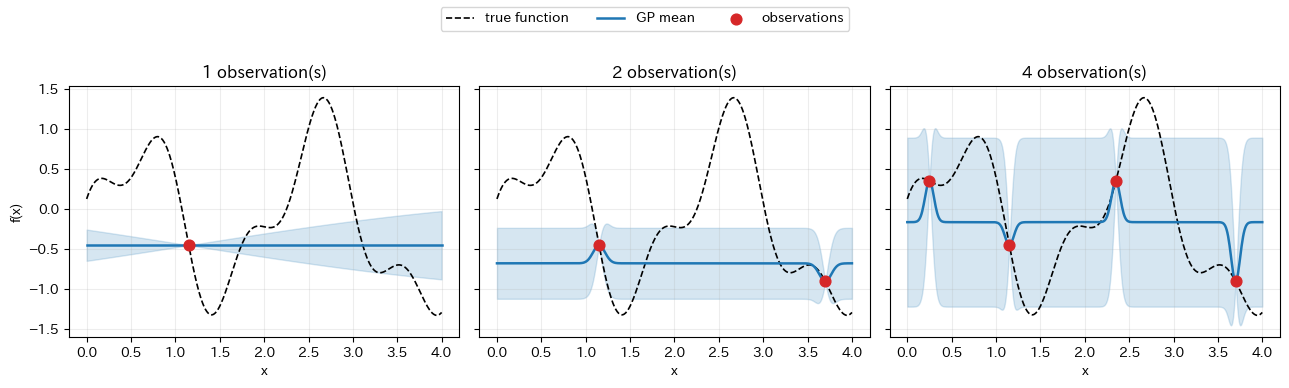

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel


def objective(x: np.ndarray) -> np.ndarray:
    """授業用の 1 次元目的関数（最大化）を返す。"""
    x = np.asarray(x)
    return np.sin(3.0 * x) + 0.45 * np.cos(7.0 * x) - 0.08 * (x - 2.0) ** 2


def fit_gp(x_train: np.ndarray, y_train: np.ndarray) -> GaussianProcessRegressor:
    """観測データから GP 回帰モデルを学習する。"""
    kernel = ConstantKernel(1.0, (0.1, 10.0)) * RBF(length_scale=0.7, length_scale_bounds=(0.05, 5.0))
    kernel += WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-2))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=8,
        random_state=0,
    )
    gp.fit(x_train.reshape(-1, 1), y_train)
    return gp

x_grid = np.linspace(0.0, 4.0, 500)
y_true = objective(x_grid)
observation_sets = [np.array([1.15]), np.array([1.15, 3.70]), np.array([0.25, 1.15, 2.35, 3.70])]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharex=True, sharey=True)
for ax, x_obs_step in zip(axes, observation_sets):
    y_obs_step = objective(x_obs_step)
    gp_step = fit_gp(x_obs_step, y_obs_step)
    mu_step, std_step = gp_step.predict(x_grid.reshape(-1, 1), return_std=True)
    ax.plot(x_grid, y_true, "k--", linewidth=1.2, label="true function")
    ax.plot(x_grid, mu_step, color="tab:blue", linewidth=1.8, label="GP mean")
    ax.fill_between(x_grid, mu_step - 1.96 * std_step, mu_step + 1.96 * std_step, color="tab:blue", alpha=0.18)
    ax.scatter(x_obs_step, y_obs_step, color="tab:red", s=60, zorder=3, label="observations")
    ax.set_title(f"{len(x_obs_step)} observation(s)")
    ax.set_xlabel("x")
    ax.grid(alpha=0.22)
axes[0].set_ylabel("f(x)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


左図では観測が 1 点しかないため，赤点の近く以外はほとんど分からない。中央図では 2 点に増えたことで，右側の不確かさが小さくなる。右図では 4 点を使っているため，平均曲線は真の関数の形に少し近づく。

ただし，真の関数を完全に復元できているわけではない。だからこそ，BO は「平均が良さそうな場所」と「まだ分かっていない場所」を獲得関数で比較する。


## 4. GP 回帰を 1 次元で見てみる

ここでは，真の関数を授業用に用意し，少数の点だけを観測したとする。実際のベイズ最適化では真の関数は未知だが，ノート上では動きを確認するために描画する。


In [6]:
x_obs = np.array([0.25, 1.15, 2.35, 3.70])
y_obs = objective(x_obs)

gp = fit_gp(x_obs, y_obs)
mu, std = gp.predict(x_grid.reshape(-1, 1), return_std=True)


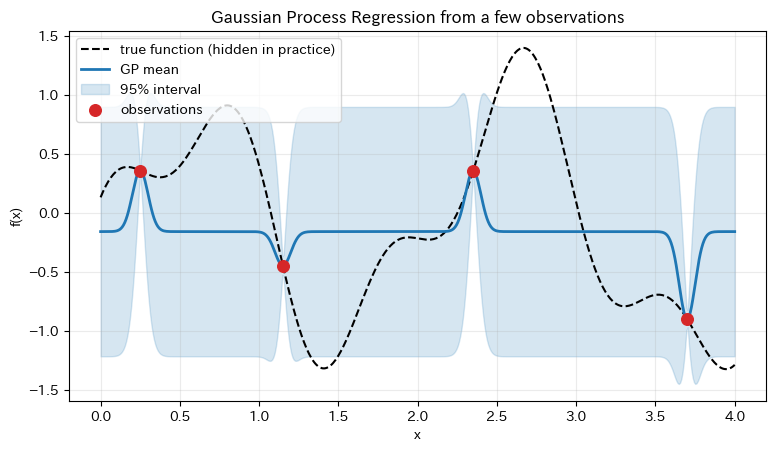

In [7]:
plt.figure(figsize=(9, 4.8))
plt.plot(x_grid, y_true, "k--", linewidth=1.5, label="true function (hidden in practice)")
plt.plot(x_grid, mu, color="tab:blue", linewidth=2.0, label="GP mean")
plt.fill_between(x_grid, mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.18, label="95% interval")
plt.scatter(x_obs, y_obs, color="tab:red", s=70, zorder=3, label="observations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gaussian Process Regression from a few observations")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.show()

図の青い線は GP の予測平均であり，青い帯は予測不確かさである。赤い観測点の近くでは帯が細く，観測点が少ない領域では帯が太い。

ベイズ最適化は，この図を見て「平均が高いところ」だけを選ぶわけではない。平均はまだ低くても，帯が太い場所には大きな値が隠れているかもしれない。この期待をどう数値化するかが獲得関数である。


## 5. 獲得関数：次に調べる点を決める

ここで GP の話から BO の話に戻ってきた。ここからは最大化問題として書く。

前節までで，GP は各候補 $\boldsymbol{x}$ に対して

$$
f(\boldsymbol{x}) \mid \text{observed data}
\sim
\mathcal{N}(\mu(\boldsymbol{x}),\sigma^2(\boldsymbol{x}))
$$

という予測分布を返すことを見た。つまり，GP から分かるのは「この点の値は高そうか」を表す平均 $\mu(\boldsymbol{x})$ と，「まだどれくらい分からないか」を表す標準偏差 $\sigma(\boldsymbol{x})$ である。

しかし BO で本当に決めたいのは，予測分布そのものではなく，**次にどの $\boldsymbol{x}$ を実際に評価するか**である。そこで，GP の出力を使って候補点に点数を付ける関数を作る。この点数付けの関数を **獲得関数**（acquisition function）と呼び，よく

$$
\alpha(\boldsymbol{x})
$$

と書く。獲得関数は目的関数 $f(\boldsymbol{x})$ そのものではない。高価な実験やシミュレーションを実行せずに，GP の予測平均・予測不確かさ・現在の最良値から計算できる「次に調べる価値」のスコアである。

したがって BO の 1 ステップは，おおまかには

$$
\boldsymbol{x}_{\mathrm{next}}
= \operatorname*{arg\,max}_{\boldsymbol{x}} \alpha(\boldsymbol{x})
$$

と書ける。つまり，獲得関数が最も大きい候補を次に評価する。

5.1〜5.3 で出てくる PI，EI，UCB は，この $\alpha(\boldsymbol{x})$ の作り方の違いである。5.4 では，それらの獲得関数のグラフをどう読むかを見る。

現在までの観測値の最大を

$$
y_{\mathrm{best}} = \max_i y_i
$$

とする。

### 5.1 Probability of Improvement（PI）

改善確率 PI は，現在の最良値を上回る確率である。

$$
\operatorname{PI}(\boldsymbol{x})
= \Pr\left(f(\boldsymbol{x}) \ge y_{\mathrm{best}} + \xi\right)
= \Phi(Z)
$$

ただし

$$
Z = \frac{\mu(\boldsymbol{x}) - y_{\mathrm{best}} - \xi}{\sigma(\boldsymbol{x})}
$$

である。$\Phi$ は標準正規分布の累積分布関数であり，$\xi \ge 0$ は改善幅の最低ラインである。

PI は分かりやすいが，「少しだけ勝てそう」な点を選びやすく，大きな改善幅をあまり評価しないことがある。

### 5.2 Expected Improvement（EI）

期待改善量 EI は，改善した場合の改善幅の期待値である。

$$
\operatorname{EI}(\boldsymbol{x})
= \mathbb{E}\left[\max(0, f(\boldsymbol{x}) - y_{\mathrm{best}} - \xi)\right]
$$

GP の予測分布が正規分布なので，閉じた形で

$$
\operatorname{EI}(\boldsymbol{x})
= (\mu(\boldsymbol{x}) - y_{\mathrm{best}} - \xi)\Phi(Z)
+ \sigma(\boldsymbol{x})\phi(Z)
$$

と書ける。ここで $\phi$ は標準正規分布の密度関数である。

第 1 項は「平均的に良さそう」な点を評価し，第 2 項は「不確かなので調べる価値がある」点を評価する。したがって EI は，活用と探索のバランスを比較的自然に取る。

### 5.3 Upper Confidence Bound（UCB）

UCB は

$$
\operatorname{UCB}(\boldsymbol{x})
= \mu(\boldsymbol{x}) + \kappa \sigma(\boldsymbol{x})
$$

である。$\kappa$ が大きいほど，不確かさの大きい点を選びやすい。最大化では UCB を最大化し，最小化では LCB（Lower Confidence Bound）

$$
\operatorname{LCB}(\boldsymbol{x})
= \mu(\boldsymbol{x}) - \kappa \sigma(\boldsymbol{x})
$$

を最小化する。


In [8]:
def probability_of_improvement(mu: np.ndarray, std: np.ndarray, best: float, xi: float = 0.01) -> np.ndarray:
    """最大化問題の Probability of Improvement を計算する。"""
    std = np.maximum(std, 1e-12)
    z = (mu - best - xi) / std
    return norm.cdf(z)


def expected_improvement(mu: np.ndarray, std: np.ndarray, best: float, xi: float = 0.01) -> np.ndarray:
    """最大化問題の Expected Improvement を計算する。"""
    std = np.maximum(std, 1e-12)
    improvement = mu - best - xi
    z = improvement / std
    return improvement * norm.cdf(z) + std * norm.pdf(z)


def upper_confidence_bound(mu: np.ndarray, std: np.ndarray, kappa: float = 2.0) -> np.ndarray:
    """最大化問題の Upper Confidence Bound を計算する。"""
    return mu + kappa * std

best_y = float(np.max(y_obs))
pi = probability_of_improvement(mu, std, best_y)
ei = expected_improvement(mu, std, best_y)
ucb = upper_confidence_bound(mu, std)

x_next_ei = x_grid[np.argmax(ei)]
x_next_ucb = x_grid[np.argmax(ucb)]


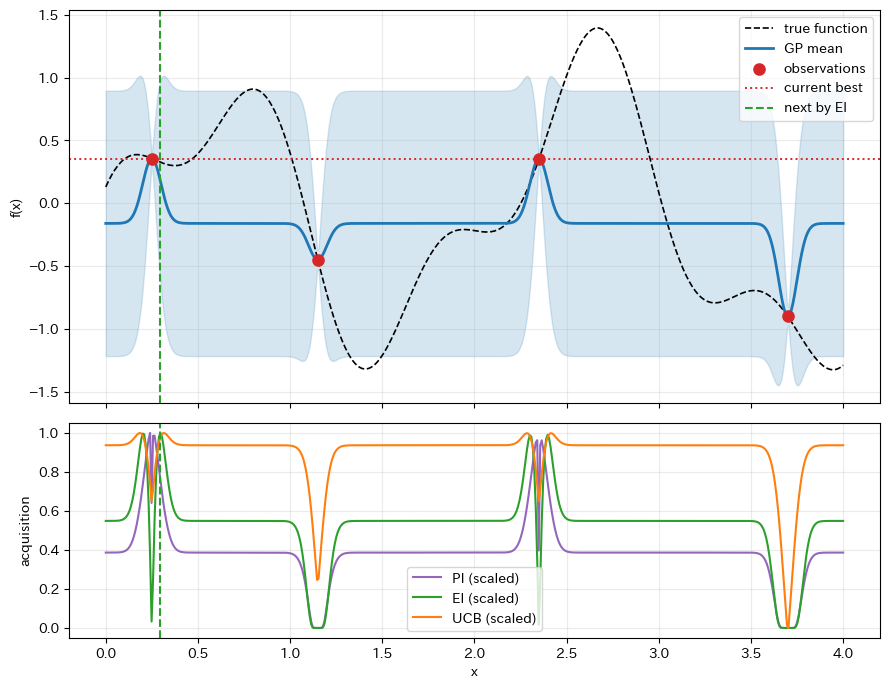

EI が次に選ぶ点: x = 0.297
UCB が次に選ぶ点: x = 0.184


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, height_ratios=[2.2, 1.2])

axes[0].plot(x_grid, y_true, "k--", linewidth=1.2, label="true function")
axes[0].plot(x_grid, mu, color="tab:blue", linewidth=2.0, label="GP mean")
axes[0].fill_between(x_grid, mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.18)
axes[0].scatter(x_obs, y_obs, color="tab:red", s=65, zorder=3, label="observations")
axes[0].axhline(best_y, color="tab:red", linestyle=":", linewidth=1.4, label="current best")
axes[0].axvline(x_next_ei, color="tab:green", linestyle="--", linewidth=1.5, label="next by EI")
axes[0].set_ylabel("f(x)")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.25)

axes[1].plot(x_grid, pi / np.max(pi), label="PI (scaled)", color="tab:purple")
axes[1].plot(x_grid, ei / np.max(ei), label="EI (scaled)", color="tab:green")
axes[1].plot(x_grid, (ucb - np.min(ucb)) / (np.max(ucb) - np.min(ucb)), label="UCB (scaled)", color="tab:orange")
axes[1].axvline(x_next_ei, color="tab:green", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("acquisition")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"EI が次に選ぶ点: x = {x_next_ei:.3f}")
print(f"UCB が次に選ぶ点: x = {x_next_ucb:.3f}")

### 5.4 獲得関数の見方

獲得関数の図では，縦軸の絶対値よりも「どの $x$ が高くなっているか」を見る。

- PI は，今の最良値を超える確率が高い場所を好む。
- EI は，超える確率だけでなく，超えたときの改善幅も見る。
- UCB は，平均が高い場所と不確かさが大きい場所の両方を，$\kappa$ で明示的に足し合わせる。

次の図では，EI を「平均による改善の候補」と「不確かさによる押し上げ」に分けて眺める。厳密には 2 項が独立に働くわけではないが，どの場所が選ばれやすいかを理解する助けになる。


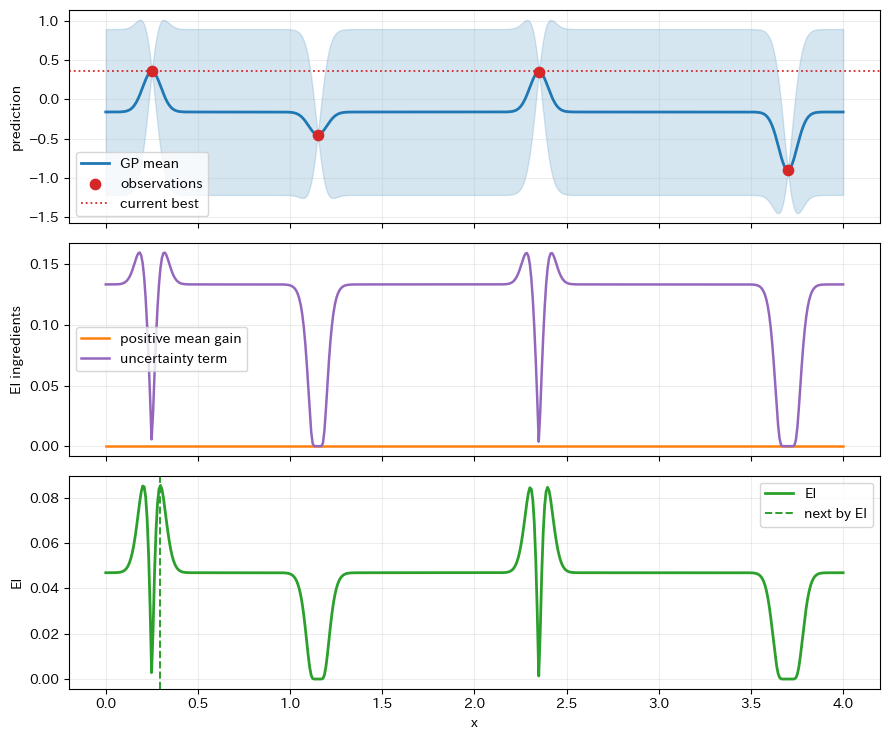

In [10]:
improvement = mu - best_y - 0.01
positive_mean_gain = np.maximum(improvement, 0.0)
uncertainty_bonus = std * norm.pdf(improvement / np.maximum(std, 1e-12))

fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
axes[0].plot(x_grid, mu, color="tab:blue", linewidth=2.0, label="GP mean")
axes[0].fill_between(x_grid, mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.18)
axes[0].scatter(x_obs, y_obs, color="tab:red", s=55, zorder=3, label="observations")
axes[0].axhline(best_y, color="tab:red", linestyle=":", linewidth=1.3, label="current best")
axes[0].set_ylabel("prediction")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.22)

axes[1].plot(x_grid, positive_mean_gain, color="tab:orange", linewidth=1.8, label="positive mean gain")
axes[1].plot(x_grid, uncertainty_bonus, color="tab:purple", linewidth=1.8, label="uncertainty term")
axes[1].set_ylabel("EI ingredients")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.22)

axes[2].plot(x_grid, ei, color="tab:green", linewidth=2.0, label="EI")
axes[2].axvline(x_next_ei, color="tab:green", linestyle="--", linewidth=1.4, label="next by EI")
axes[2].set_xlabel("x")
axes[2].set_ylabel("EI")
axes[2].legend(loc="best")
axes[2].grid(alpha=0.22)

plt.tight_layout()
plt.show()


EI が大きくなるのは，単に平均が高い場所だけではない。不確かさが残っていて，しかも改善の可能性がある場所も候補になる。この性質のおかげで，BO は同じ場所の周辺だけを調べ続けることを避けやすい。


## 6. ベイズ最適化を実装する

ここでは EI を使って，1 点ずつ観測を増やす。実装のポイントは単純である。

- 観測データで GP を学習する。
- グリッド上の候補に対して $\mu$ と $\sigma$ を計算する。
- EI が最大の点を次の評価点にする。
- 本物の目的関数を 1 回評価し，観測データに追加する。

本来は獲得関数そのものを連続最適化するが，授業では見通しを優先して細かいグリッドから選ぶ。


In [11]:
def bayesian_optimization_1d(
    x_initial: np.ndarray,
    n_iter: int = 8,
    xi: float = 0.01,
) -> tuple[np.ndarray, np.ndarray, list[dict[str, np.ndarray | float]]]:
    """1 次元の EI ベイズ最適化を実行する。"""
    x_train = np.array(x_initial, dtype=float)
    y_train = objective(x_train)
    history: list[dict[str, np.ndarray | float]] = []

    for _ in range(n_iter):
        gp = fit_gp(x_train, y_train)
        mu, std = gp.predict(x_grid.reshape(-1, 1), return_std=True)
        ei = expected_improvement(mu, std, float(np.max(y_train)), xi=xi)

        # 既に評価した点のごく近くを再選択しないようにする。
        distance_to_observed = np.min(np.abs(x_grid[:, None] - x_train[None, :]), axis=1)
        ei = np.where(distance_to_observed < 1e-3, -np.inf, ei)

        x_next = float(x_grid[np.argmax(ei)])
        y_next = float(objective(x_next))

        history.append({"x_train": x_train.copy(), "y_train": y_train.copy(), "x_next": x_next, "mu": mu, "std": std, "ei": ei.copy()})
        x_train = np.append(x_train, x_next)
        y_train = np.append(y_train, y_next)

    return x_train, y_train, history

x_final, y_final, history = bayesian_optimization_1d(np.array([0.20, 1.60, 3.80]), n_iter=8)

best_idx = int(np.argmax(y_final))
print(f"観測した点数: {len(x_final)}")
print(f"観測中の最良点: x = {x_final[best_idx]:.3f}, f(x) = {y_final[best_idx]:.3f}")
print(f"グリッド上の真の最良点: x = {x_grid[np.argmax(y_true)]:.3f}, f(x) = {np.max(y_true):.3f}")


観測した点数: 11
観測中の最良点: x = 2.685, f(x) = 1.391
グリッド上の真の最良点: x = 2.669, f(x) = 1.396


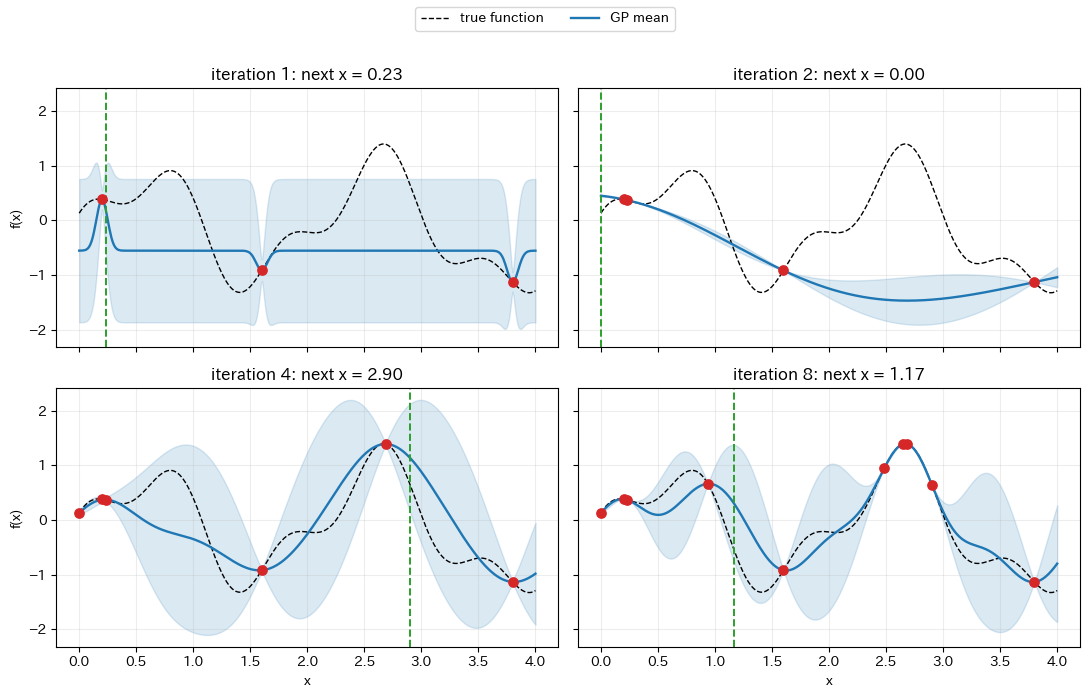

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
selected_steps = [0, 1, 3, 7]

for ax, step in zip(axes.ravel(), selected_steps):
    item = history[step]
    x_train_step = item["x_train"]
    y_train_step = item["y_train"]
    mu_step = item["mu"]
    std_step = item["std"]
    x_next = item["x_next"]

    ax.plot(x_grid, y_true, "k--", linewidth=1.0, label="true function")
    ax.plot(x_grid, mu_step, color="tab:blue", linewidth=1.7, label="GP mean")
    ax.fill_between(x_grid, mu_step - 1.96 * std_step, mu_step + 1.96 * std_step, color="tab:blue", alpha=0.16)
    ax.scatter(x_train_step, y_train_step, color="tab:red", s=45, zorder=3)
    ax.axvline(x_next, color="tab:green", linestyle="--", linewidth=1.4)
    ax.set_title(f"iteration {step + 1}: next x = {x_next:.2f}")
    ax.grid(alpha=0.22)

for ax in axes[-1, :]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("f(x)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### 6.1 観測点の増え方を時系列で見る

次の図では，BO が各反復でどの $x$ を選び，観測済み最良値がどう改善したかを見る。上の図は選ばれた $x$ の位置，下の図は「それまでに見つかった最良値」である。

BO では，各反復で必ず改善するとは限らない。探索のために不確かな場所を試した結果，値が悪いこともある。しかし，その失敗した観測も GP の不確かさを減らす情報になる。


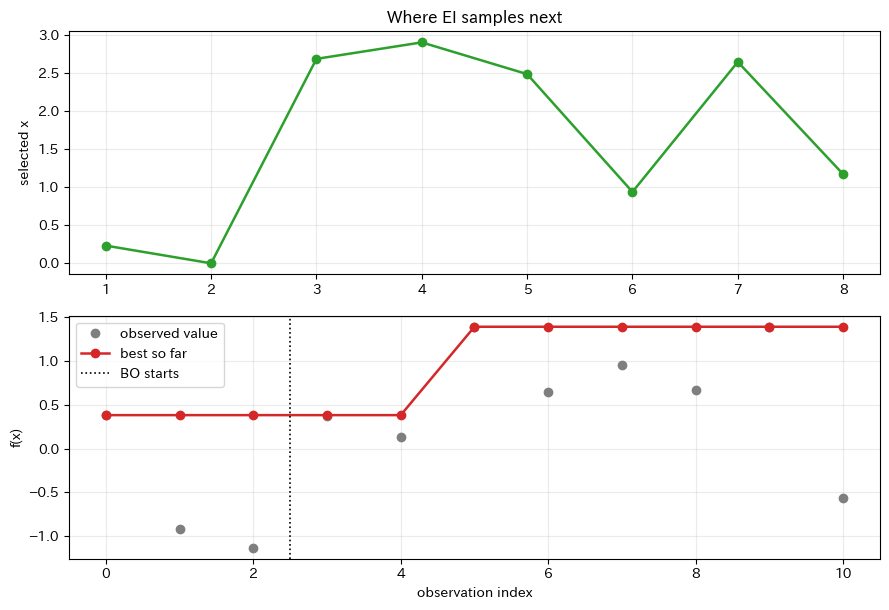

In [13]:
chosen_x = np.array([item["x_next"] for item in history], dtype=float)
chosen_y = objective(chosen_x)
initial_count = 3
all_x_sequence = x_final
all_y_sequence = y_final
best_so_far = np.maximum.accumulate(all_y_sequence)

fig, axes = plt.subplots(2, 1, figsize=(9, 6.2), sharex=False)
axes[0].plot(np.arange(1, len(chosen_x) + 1), chosen_x, marker="o", color="tab:green", linewidth=1.8)
axes[0].set_ylabel("selected x")
axes[0].set_title("Where EI samples next")
axes[0].grid(alpha=0.25)

axes[1].plot(np.arange(len(all_y_sequence)), all_y_sequence, marker="o", linestyle="", color="tab:gray", label="observed value")
axes[1].plot(np.arange(len(best_so_far)), best_so_far, marker="o", color="tab:red", linewidth=1.8, label="best so far")
axes[1].axvline(initial_count - 0.5, color="black", linestyle=":", linewidth=1.2, label="BO starts")
axes[1].set_xlabel("observation index")
axes[1].set_ylabel("f(x)")
axes[1].legend(loc="best")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


赤い点が増えるにつれて，GP の不確かさは変化する。EI は，現在の最良点の近くをさらに詰める場合もあれば，まだ観測していない領域を調べる場合もある。

ここで注意したいのは，BO は「常に最短で真の最適解へ行く魔法」ではないという点である。カーネルの仮定，初期点，ノイズ，獲得関数の種類，獲得関数の最適化方法に強く影響される。それでも，高価な評価を何度も実行できない状況では，観測済み情報を丁寧に使えることが大きな利点になる。


## 7. 最小化問題ではどう書き換えるか

このページのコードは最大化として書いた。最小化したい場合は，次のどちらかで対応できる。

1. 目的関数 $f$ を $-f$ に変換し，最大化問題として扱う。
2. 最小化用の獲得関数を直接使う。

たとえば LCB は

$$
\operatorname{LCB}(\boldsymbol{x}) = \mu(\boldsymbol{x}) - \kappa\sigma(\boldsymbol{x})
$$

を最小化する。EI も，現在の最良値を「最小値」として，改善量を

$$
\max(0, y_{\mathrm{best}} - f(\boldsymbol{x}) - \xi)
$$

のように定義すればよい。

実装では，符号を反転して最大化に統一するほうが間違いにくい。


## 8. 多目的ベイズ最適化の考え方

実際の設計では，目的が 1 つだけとは限らない。たとえば材料設計では，性能を上げたい一方で，コストや毒性や製造難易度は下げたいことがある。このような問題は

$$
\boldsymbol{f}(\boldsymbol{x})
= (f_1(\boldsymbol{x}), f_2(\boldsymbol{x}), \ldots, f_m(\boldsymbol{x}))
$$

を同時に最適化する **多目的最適化** である。

多目的では，すべての目的で他の解に負けていない解集合を **Pareto front** と呼ぶ。多目的ベイズ最適化では，目的ごとに GP を作る，または目的間の相関も含めたモデルを作り，Pareto front を効率よく改善する点を選ぶ。代表的な考え方には，期待 hypervolume 改善量（Expected Hypervolume Improvement, EHVI）などがある。

この授業では詳細な実装までは扱わないが，単目的 BO の「平均と不確かさから次の評価点を選ぶ」という発想が，多目的でも中心になる。


## 9. 実務で使うときの注意

ベイズ最適化を使うときは，次の点に注意する。

- **入力のスケーリング**: 変数ごとに単位や範囲が違うと，カーネルの距離計算が偏る。$[0,1]$ などに正規化する。
- **目的値の標準化**: GP は目的値のスケールにも影響される。実装では `normalize_y=True` のような設定を使うことが多い。
- **カテゴリ変数**: RBF カーネルは連続変数向けである。カテゴリ変数を含む場合はエンコーディングや専用カーネルを考える。
- **制約条件**: 実験できない条件，安全でない条件，失敗しやすい条件があるなら，制約付き BO として扱う。
- **高次元問題**: 次元が高いと GP も獲得関数最適化も難しくなる。重要変数の選択，埋め込み，ランダム特徴，別の代理モデルを検討する。
- **獲得関数の最適化**: 代理モデルが安く評価できても，獲得関数を最大化する問題は別の最適化問題である。

BO は「少ない評価回数で賢く試す」方法であり，「評価回数が十分に安い問題で常に最強」という意味ではない。評価が安いなら，DE や CMA-ES のように多くの点を試す方法のほうが扱いやすい場合もある。



## 10. BoTorch で実際にベイズ最適化を動かす

ここまでは，GP と獲得関数の中身が見えるように `scikit-learn` と自作関数で実装した。実務や研究では，より柔軟な BO ライブラリを使うことが多い。ここでは **BoTorch** を使って，同じ 1 次元目的関数を最適化する。

BoTorch は PyTorch 上に作られたベイズ最適化ライブラリであり，GP モデル，獲得関数，獲得関数の最適化をまとめて扱える。内部では GPyTorch が GP の計算を担当する。

手実装との対応は次の通りである。

- `SingleTaskGP`: 1 つの目的関数に対する GP 代理モデルである。
- `ExactMarginalLogLikelihood`: GP のハイパーパラメータを学習するための周辺対数尤度である。
- `fit_gpytorch_mll`: 周辺対数尤度を最大化して GP を学習する。
- `LogExpectedImprovement`: EI を数値的に安定に扱う獲得関数である。
- `optimize_acqf`: 獲得関数を最大化して次の候補点を返す。

最近の BoTorch では，通常の `ExpectedImprovement` よりも，数値的に安定な `LogExpectedImprovement` や `qLogExpectedImprovement` が推奨されることが多い。ここでは 1 点ずつ選ぶので `LogExpectedImprovement` を使う。

また，BoTorch は入力が unit cube，つまり各変数が $[0,1]$ に入るようスケーリングされていることを前提にすることが多い。この例でも，最適化用の変数を $z \in [0,1]$ とし，目的関数を評価するときだけ元の変数 $x=4z$ に戻す。


### 10.1 BoTorch の処理の流れ

BoTorch のコードは短いが，内部で行っていることは手実装と同じである。次の図のように，観測データから GP を学習し，獲得関数を作り，獲得関数の最大点を次の実験点として選ぶ。


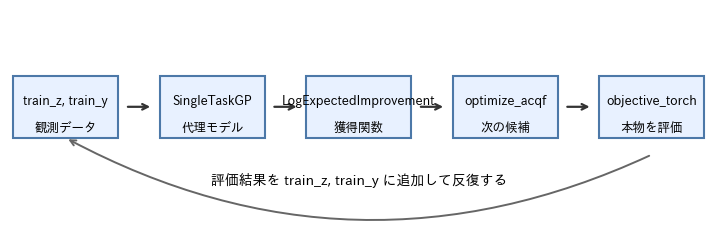

In [14]:
fig, ax = plt.subplots(figsize=(9, 2.7))
ax.axis("off")
steps = [
    ("train_z, train_y", "観測データ"),
    ("SingleTaskGP", "代理モデル"),
    ("LogExpectedImprovement", "獲得関数"),
    ("optimize_acqf", "次の候補"),
    ("objective_torch", "本物を評価"),
]
xs = np.linspace(0.08, 0.92, len(steps))
for i, (xpos, (title, subtitle)) in enumerate(zip(xs, steps)):
    box = plt.Rectangle((xpos - 0.075, 0.38), 0.15, 0.30, fill=True, color="#e8f1ff", ec="#4c78a8", lw=1.5)
    ax.add_patch(box)
    ax.text(xpos, 0.56, title, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(xpos, 0.43, subtitle, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1:
        ax.annotate("", xy=(xs[i + 1] - 0.085, 0.53), xytext=(xpos + 0.085, 0.53), arrowprops=dict(arrowstyle="->", lw=1.6, color="#333333"))
ax.text(0.50, 0.18, "評価結果を train_z, train_y に追加して反復する", ha="center", va="center", fontsize=10)
ax.annotate("", xy=(0.08, 0.38), xytext=(0.92, 0.30), arrowprops=dict(arrowstyle="->", lw=1.4, color="#666666", connectionstyle="arc3,rad=-0.25"))
plt.show()


In [15]:
import torch

from botorch.acquisition import LogExpectedImprovement
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

# BoTorch / GPyTorch は double precision が標準的である。
torch.set_default_dtype(torch.double)


def unit_to_original(z: torch.Tensor) -> torch.Tensor:
    """unit cube 上の z を元の探索変数 x in [0, 4] に戻す。"""
    return 4.0 * z


def objective_torch(z: torch.Tensor) -> torch.Tensor:
    """BoTorch 用の目的関数（最大化）を返す。"""
    x = unit_to_original(z)
    return torch.sin(3.0 * x) + 0.45 * torch.cos(7.0 * x) - 0.08 * (x - 2.0) ** 2


def fit_botorch_gp(train_z: torch.Tensor, train_y: torch.Tensor) -> SingleTaskGP:
    """BoTorch の SingleTaskGP を学習する。"""
    model = SingleTaskGP(train_z, train_y)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model

bounds = torch.tensor([[0.0], [1.0]], dtype=torch.double)
train_z = torch.tensor([[0.05], [0.40], [0.95]], dtype=torch.double)
train_y = objective_torch(train_z)

botorch_history = []

for iteration in range(8):
    model = fit_botorch_gp(train_z, train_y)
    acq_func = LogExpectedImprovement(model=model, best_f=train_y.max())

    candidate_z, acq_value = optimize_acqf(
        acq_function=acq_func,
        bounds=bounds,
        q=1,
        num_restarts=8,
        raw_samples=128,
    )

    new_y = objective_torch(candidate_z)
    candidate_x = unit_to_original(candidate_z)
    botorch_history.append(
        {
            "iteration": iteration + 1,
            "x_next": float(candidate_x.item()),
            "z_next": float(candidate_z.item()),
            "y_next": float(new_y.item()),
            "best_y": float(torch.maximum(train_y.max(), new_y.max()).item()),
        }
    )

    train_z = torch.cat([train_z, candidate_z], dim=0)
    train_y = torch.cat([train_y, new_y], dim=0)

train_x = unit_to_original(train_z)
best_index = int(torch.argmax(train_y).item())
print(f"BoTorch で観測した点数: {len(train_x)}")
print(f"BoTorch の観測中の最良点: x = {train_x[best_index].item():.3f}, f(x) = {train_y[best_index].item():.3f}")
print("各反復で選ばれた点:")
for item in botorch_history:
    print(f"  iter {item['iteration']:2d}: z = {item['z_next']:.3f}, x = {item['x_next']:.3f}, f(x) = {item['y_next']:.3f}, best = {item['best_y']:.3f}")


BoTorch で観測した点数: 11
BoTorch の観測中の最良点: x = 2.677, f(x) = 1.395
各反復で選ばれた点:
  iter  1: z = 0.138, x = 0.554, f(x) = 0.494, best = 0.494
  iter  2: z = 0.120, x = 0.478, f(x) = 0.365, best = 0.494
  iter  3: z = 0.113, x = 0.454, f(x) = 0.337, best = 0.494
  iter  4: z = 0.208, x = 0.832, f(x) = 0.896, best = 0.896
  iter  5: z = 0.233, x = 0.931, f(x) = 0.687, best = 0.896
  iter  6: z = 0.669, x = 2.677, f(x) = 1.395, best = 1.395
  iter  7: z = 0.718, x = 2.872, f(x) = 0.803, best = 1.395
  iter  8: z = 0.626, x = 2.505, f(x) = 1.038, best = 1.395



BoTorch では，獲得関数の最大化も `optimize_acqf` に任せる。先ほどの手実装ではグリッド上から次の点を選んだが，BoTorch は連続空間上で獲得関数を最適化する。このとき最適化している変数は $z \in [0,1]$ であり，図では元の変数 $x=4z$ に戻して表示する。

次の図では，最終的に BoTorch が観測した点を赤で示す。真の関数は授業用に見せているだけで，BoTorch の最適化には使っていない。


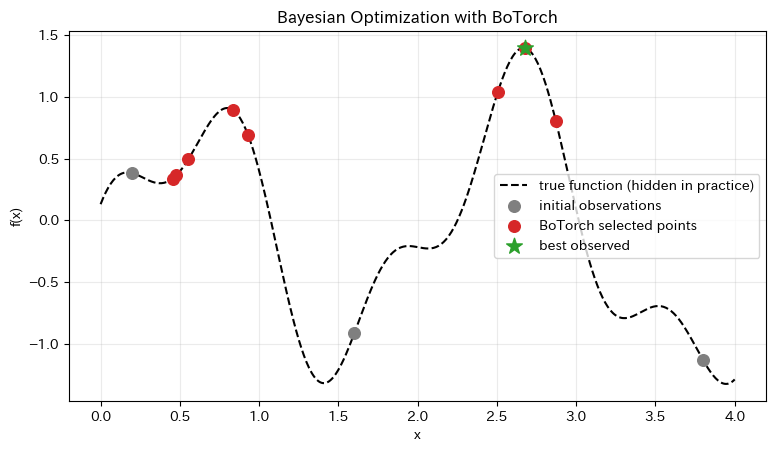

In [16]:

final_x_np = train_x.detach().cpu().numpy().ravel()
final_y_np = train_y.detach().cpu().numpy().ravel()

plt.figure(figsize=(9, 4.8))
plt.plot(x_grid, y_true, "k--", linewidth=1.5, label="true function (hidden in practice)")
plt.scatter(final_x_np[:3], final_y_np[:3], color="tab:gray", s=70, label="initial observations", zorder=3)
plt.scatter(final_x_np[3:], final_y_np[3:], color="tab:red", s=70, label="BoTorch selected points", zorder=3)
plt.scatter(final_x_np[best_index], final_y_np[best_index], color="tab:green", s=140, marker="*", label="best observed", zorder=4)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Bayesian Optimization with BoTorch")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.show()



### 10.2 手実装と BoTorch の使い分け

授業では，まず手実装で GP と EI の意味を確認し，その後に BoTorch を使う流れがよい。理由は，ライブラリだけを先に使うと，`model`，`mll`，`acq_func`，`bounds` が何をしているのか見えにくいからである。

一方で，実務では BoTorch のようなライブラリを使う利点が大きい。

- 獲得関数の連続最適化を自分で書かなくてよい。
- バッチ候補点を同時に選ぶ `qLogExpectedImprovement` などへ拡張しやすい。
- GPU，制約付き BO，多目的 BO，入力変換，出力変換などへ進みやすい。
- PyTorch のテンソルで目的関数やシミュレータと接続しやすい。

このノートでは 1 次元の小さな例にしているが，BoTorch は本来，より複雑な実験計画やハイパーパラメータ最適化で力を発揮する。


## 11. まとめ

- ベイズ最適化は，高価なブラックボックス関数を少ない評価回数で最適化する逐次的な方法である。
- 代理モデルは，目的関数の予測平均だけでなく予測不確かさも返す必要がある。
- ガウス過程回帰では，カーネルにより「近い入力は近い値を取りやすい」という仮定を置き，観測データで条件付けた予測分布を得る。
- 獲得関数は，予測平均と予測不確かさを組み合わせて，次に評価する候補を選ぶ。
- EI，PI，UCB は代表的な獲得関数であり，探索と活用のバランスの取り方が少しずつ違う。
- 実務では，スケーリング，ノイズ，制約，カテゴリ変数，高次元性に注意する。
- BoTorch のような実務ライブラリでは，GP 学習，獲得関数，獲得関数最適化を部品として組み合わせる。

次の演習では，`objective` を別の関数に変えたり，初期点を変えたり，EI ではなく UCB で点を選んだりして，探索の挙動がどう変わるかを観察するとよい。


## 参考リンク

- [ベイズ最適化(Bayesian Optimization, BO)〜実験計画法で使ったり，ハイパーパラメータを最適化したり〜](https://datachemeng.com/bayesianoptimization/)
- [ベイズ最適化の基礎とPython実装](https://yuhi-sa.github.io/posts/20260223_bayesian_optimization/1/)
- [初心者にも分かるベイズ最適化入門](https://zenn.dev/umibudou/articles/b909edf7123c0a)
- [多目的ベイズ最適化 | 複数の目的を最適化する手法を基礎から実装まで解説](https://aixtal.com/blog-multi-bo/)
- [初心者向け ガウス過程回帰をわかりやすく説明〜Pythonで実装してみた〜](https://boritaso-blog.com/gaussian-process-regression/)
